In [1]:
%run stochastic_lite.ipynb

In [2]:
####################
# Inputs
####################

# PSD ~ 1e-42 strain^2 / Hz
# PSD = 2 sigma**2 * deltaT = 2 * sigma**2 / Fs
# = sigma**2 / 512
# sigma = sqrt(1e-42 * 512)

sigma             = np.sqrt(512 * 1e-42) # strain
sigma_inj         = sigma/10.
NSegments         = 50
Fs                = 1024. # Hz
segmentDuration   = 64.0 # s
t0                = 0 # s
TAvg              = 4.0 # s

####################
# Computed quantities
####################

NSamplesPerSegment=int(segmentDuration*Fs) 
deltaT=1/Fs
fNyquist=1/(2*deltaT)
deltaF=1/segmentDuration
deltaFcg=1/TAvg
NAvgs = 2 * int(segmentDuration / TAvg) - 1
jobDuration = NSegments * segmentDuration

In [3]:
# Theoretical PSD and sigma for white GWB and white noise

Nfreqs = int((Fs/2) / deltaFcg)
alpha=3 # white signal
fref=25

w1w2bar, w1w2squaredbar,_,_ = window_factors(NSamplesPerSegment)
PSD_theor = 2*(sigma**2)*deltaT
Pgw_theor = 2*(sigma_inj**2)*deltaT

H_theor = (3*H0**2)/(10*np.pi**2*fref**3) # don't need *(P1.freqs/fref)**(alpha-3) for alpha=3
Y_theor = Pgw_theor/H_theor

var_theor = 1./((segmentDuration)*2*Nfreqs*deltaFcg * H_theor**2/(PSD_theor**2))
var_theor = w1w2squaredbar / w1w2bar**2 * var_theor
sigma_theor = np.sqrt(var_theor)

print('sigma_theor =', sigma_theor)
print('Y_theor =', Y_theor)

sigma_theor = 0.0002666003559166893
Y_theor = 0.0004894401662160896


In [4]:
# simulate the time series data
noise1=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
noise2=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
inj=sigma_inj*np.random.randn(int(NSamplesPerSegment*NSegments))

times=np.arange(t0,t0+NSegments*segmentDuration,1/Fs)

d1=TimeSeries(times,noise1 + inj)
d2=TimeSeries(times,noise2 + inj)

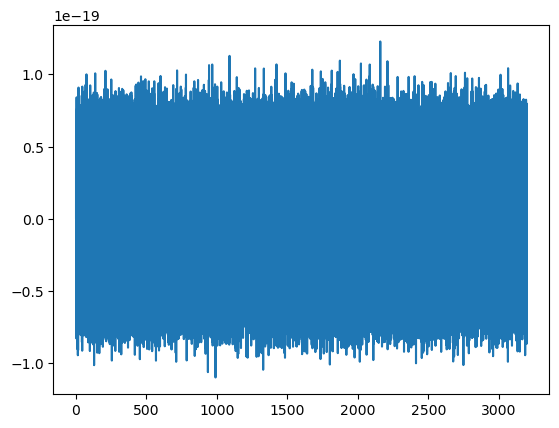

In [5]:
plt.plot(d1.times, d1.data)

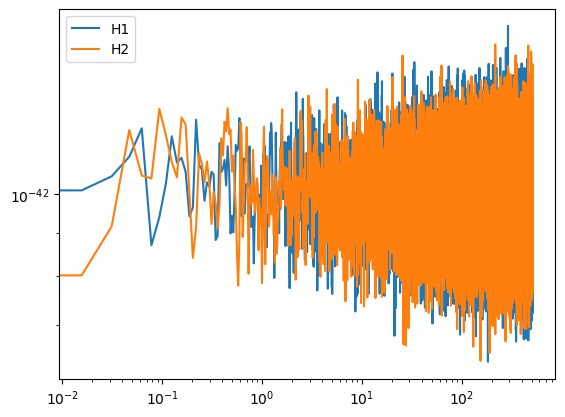

In [6]:
nperseg=int(d1.Fs/deltaF)
freqs,P1_test = welch_psd(d1.data,nperseg=nperseg,window='Hann',fs=d1.Fs)
freqs,P2_test = welch_psd(d2.data,nperseg=nperseg,window='Hann',fs=d2.Fs)

plt.loglog(freqs,P1_test,label='H1')
plt.loglog(freqs,P2_test,label='H2')
plt.legend()

In [7]:
# run stochastic pipeline
nperseg = int(fNyquist/deltaFcg)
freqs = np.linspace(0, 1/(2*deltaT), nperseg)
f_filter = freqs>0.

alpha=3
fref=25
Ys, sigs, Y_fs, var_fs, Y0_fs, var0_fs, segmentStartTimes, freqs=stochastic_old(d1,d2,segmentDuration,deltaFcg,f_filter,
                                                                            fref=fref,alpha=alpha)

/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/4269698541.py:109: RuntimeWarning: divide by zero encountered in divide
  S0 = FrequencySeries(freqs, (3*H0**2)/(10*np.pi**2*freqs**3))
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/4269698541.py:110: RuntimeWarning: invalid value encountered in multiply
  S_alpha = FrequencySeries(freqs, S0.data * (freqs/fref)**alpha )
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/4269698541.py:119: ComplexWarning: Casting complex values to real discards the imaginary part
  Y0_fs[:,II],var0_fs[:,II] = Y0_f.data, var0_f.data
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/4269698541.py:131: ComplexWarning: Casting complex values to real discards the imaginary part
  Y_fs[:,II],var_fs[:,II] = Y_f.data, var_f.data
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/4269698541.py:137: ComplexWarning: Casting complex values to real discards the imaginary part
  Ys[II], sigs[

stochastic: Done with Interval 1 / 95
	Y       = 5.018541e-04
	sigma   = 2.653040e-04
	SNR     = 1.891619
stochastic: Done with Interval 2 / 95
	Y       = 4.846095e-04
	sigma   = 2.648589e-04
	SNR     = 1.829689
stochastic: Done with Interval 3 / 95
	Y       = 1.245265e-04
	sigma   = 2.638002e-04
	SNR     = 0.472048
stochastic: Done with Interval 4 / 95
	Y       = 5.019260e-04
	sigma   = 2.655104e-04
	SNR     = 1.890419
stochastic: Done with Interval 5 / 95
	Y       = 7.246692e-04
	sigma   = 2.661000e-04
	SNR     = 2.723296
stochastic: Done with Interval 6 / 95
	Y       = 5.870391e-04
	sigma   = 2.658580e-04
	SNR     = 2.208093
stochastic: Done with Interval 7 / 95
	Y       = 3.394649e-04
	sigma   = 2.656041e-04
	SNR     = 1.278086
stochastic: Done with Interval 8 / 95
	Y       = 7.722330e-04
	sigma   = 2.652125e-04
	SNR     = 2.911752
stochastic: Done with Interval 9 / 95
	Y       = 8.971518e-04
	sigma   = 2.649253e-04
	SNR     = 3.386433
stochastic: Done with Interval 10 / 95
	Y     

In [8]:
print(Y0_fs)
print(var0_fs)

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 4.55030190e-09 -1.85976013e-08 -2.14419612e-08 ... -1.19202398e-08
   2.30507390e-08  3.36018758e-09]
 [ 2.84594723e-09  8.57285454e-08 -8.84753603e-08 ... -9.62219774e-08
  -9.07192441e-08  4.35435157e-08]
 ...
 [ 2.25805274e+01  9.90680998e+01 -5.92909464e+01 ... -1.68335546e+02
  -8.69000946e+01  3.94774756e+01]
 [ 5.59168459e+01  1.69839865e+02 -1.09587601e+02 ... -1.56052488e+01
  -1.42045280e+01  9.54817075e+01]
 [ 5.03417812e+01  1.04972625e+01  2.31190509e+02 ... -2.43461010e+01
   7.07498052e+01  4.30057644e+00]]
[[           inf            inf            inf ...            inf
             inf            inf]
 [1.86862397e-16 2.21349928e-16 1.45082548e-16 ... 1.21201066e-16
  1.05697429e-16 1.09808737e-16]
 [9.46714337e-15 1.21529402e-14 1.08478645e-14 ... 1.02487324e-14
  6.56277730e-15 9.30566063e-15]
 ...
 [1.14472297e+04 9.44687420e+03 6.77788404e+03 ... 1.12997139e

In [9]:
# ALTERNATIVE CALCULATION!!!
# first combine spectra over segments

Y0_f,var0_f=postprocessing_spectra_old(Y0_fs,var0_fs,jobDuration,segmentDuration,deltaFcg,deltaT)

# then combine over freqs, weighting as appropriate
Y_opt_alt,sig_opt_alt=calc_Y_sigma_from_Yf_varf_old(Y0_f[f_filter], var0_f[f_filter],freqs=freqs[f_filter],alpha=3,fref=25)

print('Y_opt_alt =', Y_opt_alt)
print('sig_opt_alt =', sig_opt_alt)

Y_opt_alt = 0.0005158859492344812
sig_opt_alt = 2.8809883204863836e-05


/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/440868222.py:28: RuntimeWarning: divide by zero encountered in divide
  v_f_o = 1./np.sum(1./var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/440868222.py:29: RuntimeWarning: divide by zero encountered in divide
  v_f_e = 1./np.sum(1./var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/440868222.py:33: RuntimeWarning: invalid value encountered in multiply
  Y_f_o = X_f_o * v_f_o
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/440868222.py:34: RuntimeWarning: invalid value encountered in multiply
  Y_f_e = X_f_e * v_f_e
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/440868222.py:43: RuntimeWarning: invalid value encountered in divide
  Y_f = ( X_f_o*(1- 0.5*k*v_o * sig_m2) + X_f_e*(1. - 0.5*k*v_e * sig_m2)) / (1./v_f_o + 1./v_f_e - k*sig_m2_f)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/440868222.py

In [10]:
print(Y0_f)
print(var0_f)

[            nan  1.87967915e-09  8.03624450e-09 ... -1.18537298e+01
  7.33049049e+00 -4.73855805e+00]
[           inf 1.84135198e-18 1.16091396e-16 ... 1.13209255e+02
 1.14648899e+02 1.26339838e+02]


In [11]:
# run stochastic pipeline
Y_fs, var_fs, segmentStartTimes, freqs=stochastic(d1,d2,segmentDuration,deltaFcg)

stochastic: Done with Interval 1 / 95
stochastic: Done with Interval 2 / 95
stochastic: Done with Interval 3 / 95
stochastic: Done with Interval 4 / 95
stochastic: Done with Interval 5 / 95
stochastic: Done with Interval 6 / 95
stochastic: Done with Interval 7 / 95
stochastic: Done with Interval 8 / 95
stochastic: Done with Interval 9 / 95
stochastic: Done with Interval 10 / 95
stochastic: Done with Interval 11 / 95
stochastic: Done with Interval 12 / 95


/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/1434823410.py:102: RuntimeWarning: divide by zero encountered in divide
  S0 = FrequencySeries(freqs, (3*H0**2)/(10*np.pi**2*freqs**3))
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/1434823410.py:106: ComplexWarning: Casting complex values to real discards the imaginary part
  Y_fs[:,II] = Y_fs_data / w1w2bar


stochastic: Done with Interval 13 / 95
stochastic: Done with Interval 14 / 95
stochastic: Done with Interval 15 / 95
stochastic: Done with Interval 16 / 95
stochastic: Done with Interval 17 / 95
stochastic: Done with Interval 18 / 95
stochastic: Done with Interval 19 / 95
stochastic: Done with Interval 20 / 95
stochastic: Done with Interval 21 / 95
stochastic: Done with Interval 22 / 95
stochastic: Done with Interval 23 / 95
stochastic: Done with Interval 24 / 95
stochastic: Done with Interval 25 / 95
stochastic: Done with Interval 26 / 95
stochastic: Done with Interval 27 / 95
stochastic: Done with Interval 28 / 95
stochastic: Done with Interval 29 / 95
stochastic: Done with Interval 30 / 95
stochastic: Done with Interval 31 / 95
stochastic: Done with Interval 32 / 95
stochastic: Done with Interval 33 / 95
stochastic: Done with Interval 34 / 95
stochastic: Done with Interval 35 / 95
stochastic: Done with Interval 36 / 95
stochastic: Done with Interval 37 / 95
stochastic: Done with Int

In [12]:
# first combine spectra over segments

Y_f,var_f=postprocess_narrowband(Y_fs,var_fs,jobDuration,segmentDuration,deltaFcg,deltaT)

# then combine over freqs, weighting as 
alpha = 3
fref = 25
f_filter=freqs>0.
Y_opt,sig_opt=combine_spectra_over_frequency(Y_f[f_filter], var_f[f_filter],freqs=freqs[f_filter],alpha=alpha,fref=fref)

print('Y_opt =', Y_opt)
print('sig_opt =', sig_opt)

Y_opt = 0.0005158859492344812
sig_opt = 2.8809883204863836e-05


/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/1500498407.py:27: RuntimeWarning: divide by zero encountered in divide
  v_f_o = 1./np.sum(1./var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/1500498407.py:28: RuntimeWarning: divide by zero encountered in divide
  v_f_e = 1./np.sum(1./var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/1500498407.py:32: RuntimeWarning: invalid value encountered in multiply
  Y_f_o = X_f_o * v_f_o
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/1500498407.py:33: RuntimeWarning: invalid value encountered in multiply
  Y_f_e = X_f_e * v_f_e
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/1500498407.py:42: RuntimeWarning: invalid value encountered in divide
  Y_f = ( X_f_o*(1- 0.5*k*v_o * sig_m2) + X_f_e*(1. - 0.5*k*v_e * sig_m2)) / (1./v_f_o + 1./v_f_e - k*sig_m2_f)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_13974/1500498

In [13]:
print(Y_fs)
print(var_fs)

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 4.55030190e-09 -1.85976013e-08 -2.14419612e-08 ... -1.19202398e-08
   2.30507390e-08  3.36018758e-09]
 [ 2.84594723e-09  8.57285454e-08 -8.84753603e-08 ... -9.62219774e-08
  -9.07192441e-08  4.35435157e-08]
 ...
 [ 2.25805274e+01  9.90680998e+01 -5.92909464e+01 ... -1.68335546e+02
  -8.69000946e+01  3.94774756e+01]
 [ 5.59168459e+01  1.69839865e+02 -1.09587601e+02 ... -1.56052488e+01
  -1.42045280e+01  9.54817075e+01]
 [ 5.03417812e+01  1.04972625e+01  2.31190509e+02 ... -2.43461010e+01
   7.07498052e+01  4.30057644e+00]]
[[           inf            inf            inf ...            inf
             inf            inf]
 [1.86862397e-16 2.21349928e-16 1.45082548e-16 ... 1.21201066e-16
  1.05697429e-16 1.09808737e-16]
 [9.46714337e-15 1.21529402e-14 1.08478645e-14 ... 1.02487324e-14
  6.56277730e-15 9.30566063e-15]
 ...
 [1.14472297e+04 9.44687420e+03 6.77788404e+03 ... 1.12997139e

In [14]:
print(Y_f)
print(var_f)

[            nan  1.87967915e-09  8.03624450e-09 ... -1.18537298e+01
  7.33049049e+00 -4.73855805e+00]
[           inf 1.84135198e-18 1.16091396e-16 ... 1.13209255e+02
 1.14648899e+02 1.26339838e+02]


07:01 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
07:02 bilby INFO    : Analysis priors:
07:02 bilby INFO    : A=Uniform(minimum=1e-10, maximum=0.001, name='A', latex_label='A', unit=None, boundary=None)
07:02 bilby INFO    : alpha=Uniform(minimum=-5, maximum=5, name='alpha', latex_label='alpha', unit=None, boundary=None)
07:02 bilby INFO    : Analysis likelihood class: <class '__main__.BasicPowerLawGWBLikelihood'>
07:02 bilby INFO    : Analysis likelihood noise evidence: -1880.990023791332
07:02 bilby INFO    : Single likelihood evaluation took 1.299e-04 s
07:02 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 500, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None, 

4572it [00:05, 724.77it/s, bound:108 nc: 16 ncall:8.3e+04 eff:5.5% logz-ratio=153.67+/-nan dlogz:0.115>0.1]      

07:02 bilby INFO    : Written checkpoint file outdir/GWB_powerlaw_resume.pickle


4637it [00:07, 654.24it/s, bound:110 nc:  1 ncall:8.5e+04 eff:6.1% logz-ratio=153.78+/-0.11 dlogz:0.000>0.1]

07:02 bilby INFO    : Rejection sampling nested samples to obtain 1364 posterior samples
07:02 bilby INFO    : Sampling time: 0:00:07.085983
07:02 bilby INFO    : Summary of results:
nsamples: 1364
ln_noise_evidence: -1880.990
ln_evidence: -1727.213 +/-  0.136
ln_bayes_factor: 153.777 +/-  0.136



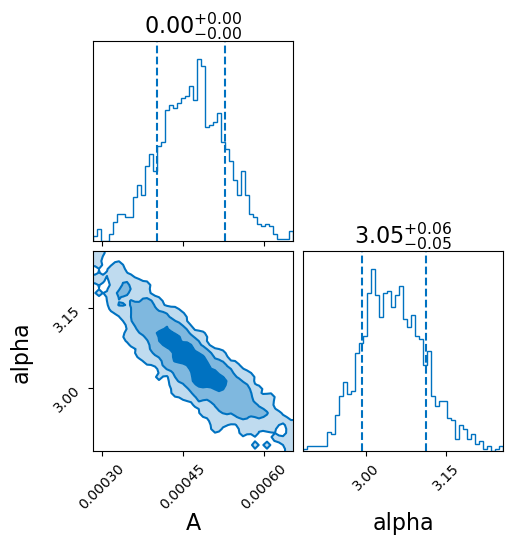

In [15]:
# A few simple setup steps
label = 'GWB_powerlaw'
outdir = 'outdir'

cleanup_dir(outdir)

Amin,Amax,alpha_min,alpha_max=1e-10,1e-3,-5,5
fref=25

likelihood = BasicPowerLawGWBLikelihood(Y0_f[1:],var0_f[1:],freqs[1:],fref)
priors = dict(A=bilby.core.prior.Uniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Uniform(alpha_min,alpha_max, 'alpha'))

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=50000)
result.plot_corner()

In [16]:
A=result.samples[:,0]
alpha=result.samples[:,1]

Text(0.5, 0, '')

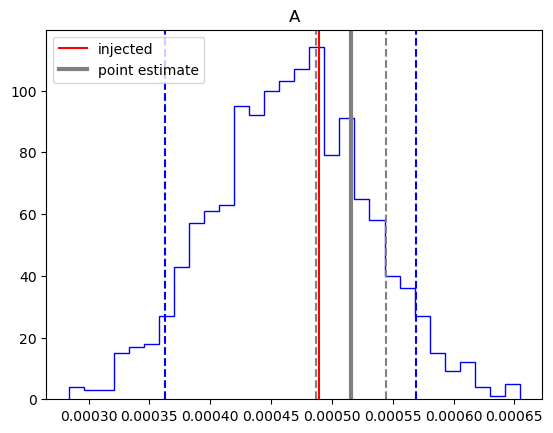

In [17]:
plt.hist(A,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(A,5),color='blue',linestyle='--')
plt.axvline(np.percentile(A,95),color='blue',linestyle='--')

plt.axvline(Y_theor,color='red', label='injected')

plt.axvline(Y_opt,color='grey', linewidth=3, label='point estimate')
plt.axvline(Y_opt+sig_opt,color='grey', linestyle='--')
plt.axvline(Y_opt-sig_opt,color='grey', linestyle='--')

plt.legend()

plt.title('A')
plt.xlabel('')

Text(0.5, 0, '')

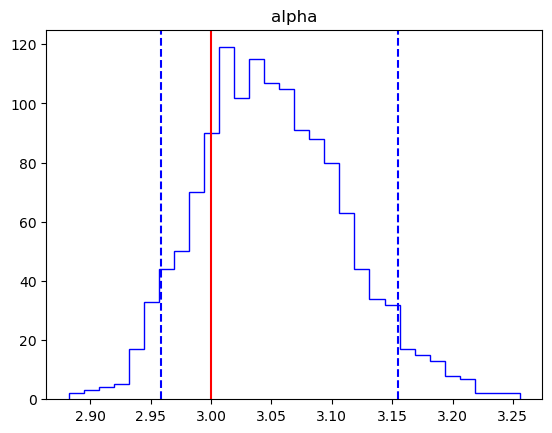

In [18]:
plt.hist(alpha,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(alpha,5),color='blue',linestyle='--')
plt.axvline(np.percentile(alpha,95),color='blue',linestyle='--')

plt.axvline(3,color='red')

plt.title('alpha')
plt.xlabel('')